# Descriptive Implementation of Linear Regression 

1. Using Sci-kit Learn 
2. From Scrach without Basis 
3. From Scrach With Basis 

The detailed survey on Linear Regression is available on https://sites.google.com/view/nishanka/machine-learning-deep-learning

Importing libraries 

In [58]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import random

Generating Dataset

In [3]:
# 1. Generate sample data (X must be 2D, y is 1D)
np.random.seed(42)
X = np.round(np.random.rand(100, 1), 2) * 10  # Independent variable (e.g., house size)
y = 2.5 * X + np.random.randn(100, 1) * 2 + 5  # Dependent variable (e.g., price)

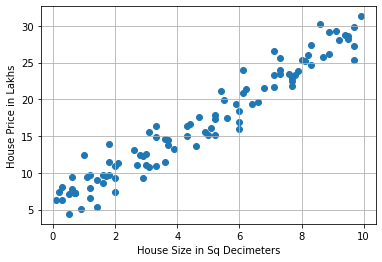

In [4]:
plt.scatter(X,y)
plt.xlabel("House Size in Sq Decimeters")
plt.ylabel("House Price in Lakhs")
plt.grid()
plt.show()

Without spliting Data

In [12]:
model = LinearRegression()
model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
y_pred = model.predict(X)

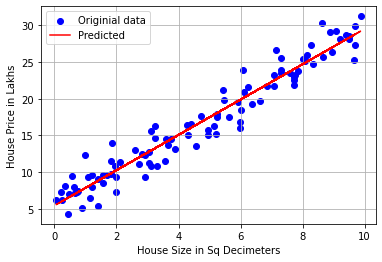

In [18]:

plt.scatter(X,y, color = "blue", label = "Originial data")
plt.plot(X,y_pred, color = "red" , label = "Predicted")
plt.xlabel("House Size in Sq Decimeters" )
plt.ylabel("House Price in Lakhs")
plt.grid()
plt.legend()
plt.show()

With Spliting dataset 

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
y_pred = model.predict(X_test)

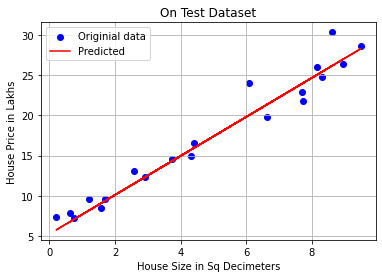

In [23]:
plt.scatter(X_test,y_test, color = "blue", label = "Originial data")
plt.plot(X_test,y_pred, color = "red" , label = "Predicted")
plt.xlabel("House Size in Sq Decimeters" )
plt.ylabel("House Price in Lakhs")
plt.title("On Test Dataset")
plt.grid()
plt.legend()
plt.show()

In [ ]:
print(f"Intercept (w0): {model.intercept_[0]:.4f}")
print(f"Slope/Coefficient (w1): {model.coef_[0][0]:.4f}")

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared Score (R²): {r2:.4f}")

Intercept (w0): 5.2858
Slope/Coefficient (w1): 2.4197
Mean Squared Error (MSE): 2.6148
R-squared Score (R²): 0.9546


---

Implementation from Scrach without Basis 

---

In [41]:
X = np.array(X)

In [42]:
import random
w = np.array([round(random.random(), 2) for _ in range(X.shape[0])]).reshape(-1, 1)

In [43]:
w[:5]

array([[0.09],
       [0.48],
       [0.72],
       [0.63],
       [0.78]])

In [44]:
X[:5]

array([[3.7],
       [9.5],
       [7.3],
       [6. ],
       [1.6]])

In [45]:
w = np.linalg.inv(X.T @ X) @ X.T @ y

In [46]:
y_pred = X @ w

In [47]:
print("Weight =", w)

Weight = [[3.23503949]]


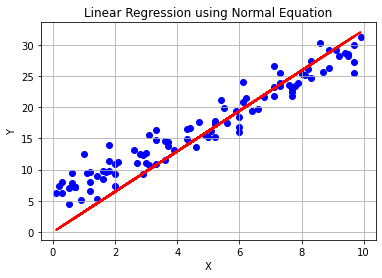

In [48]:
plt.scatter(X, y, color='blue')
plt.plot(X, y_pred, color='red', linewidth=2)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression using Normal Equation")
plt.grid(True)
plt.show()

---

Implementation of Linear Regression with Basis

---

In [49]:
w = np.array([round(random.random(), 2) for _ in range(X.shape[0])]).reshape(-1, 1)

Add Bias Column

In [50]:
X_bias = np.hstack((np.ones((X.shape[0], 1)), X))

$θ = (XᵀX)^{(-1)} Xᵀy$

In [51]:
theta = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y

In [57]:
theta

array([[5.43255257],
       [2.40756681]])

Extract parameters

In [52]:
b = theta[0,0]
w = theta[1,0]

In [53]:

print("Bias (b)   =", b)
print("Weight (w) =", w)

Bias (b)   = 5.432552573222295
Weight (w) = 2.407566809790131


Prediction 

In [54]:
y_pred = X_bias @ theta

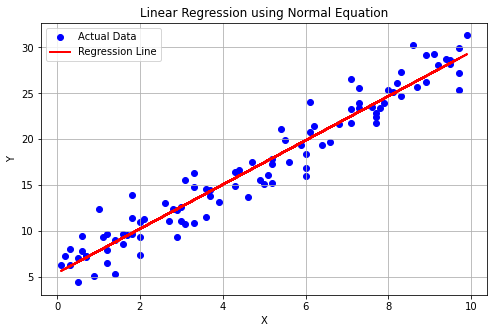

In [55]:
plt.figure(figsize=(8,5))
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, y_pred, color='red', linewidth=2, label='Regression Line')

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression using Normal Equation")
plt.legend()
plt.grid(True)
plt.show()